<hr/>
<b>Nombre</b>: Jesus David Serpa Pajaro


## Enunciado

**Objetivo**: El objetivo de esta tarea es poner a prueba la idea de que es posible simular un  sistema de N-cuerpos jerarquicos usando un *árbol* de sistemas de 2 cuerpos.

En particular compararemos la predicción de las posiciones que para un sistema múltiple de estrellas nos da la simulación con un sistema jerárquico y el mismo resultado pero calculado como si el sistema fuera un sistema de N cuerpos completo.

**Procedimiento**:

El sistema que simularemos es el de un sistema binario formado por dos estrellas "s" y "e".  Alrededor de la estrella "e" gira un planeta "p", a cuyo alrededor, a su vez, gira una luna "L".  Los datos de los cuerpos, dados en unidades canónicas, en las que $U_M = 80$ M$_{\rm Jup}$, $U_L = 0.01$ au, son.

- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.

- Condiciones iniciales (las posiciones están dadas respecto al cuerpo más masivo de cada subsistema):

   - Sistema p-L:
     - Posición inicial de p : r = [0,0,0]
     - Velocidad inicial de p: v = [0,0,0]
     - Posición inicial de L: r = [0.03,0,0]
     - Velocidad inicial de L: v = [0,0.4,0.1]

   - Sistema e-pL (baricentro de p y L):
     - Posición inicial de e : r = [0,0,0]
     - Velocidad inicial de e: v = [0,0,0]
     - Posición inicial de pL: r = [0,0.4,0]
     - Velocidad inicial de pL: v = [0.9,0,0.2]
     
  - Sistema s-epL (baricentro e y pL):
     - Posición inicial de s : r = [0,0,0]
     - Velocidad inicial de s: v = [0,0,0]
     - Posición inicial de epL: r = [2,3,0]
     - Velocidad inicial de epL: v = [-0.2,0.7,0]



Una vez definidas las condiciones iniciales:

1. Dibujar el árbol del sistema jerárquico como lo hicimos en clase.

2. Simular usando `ncuerpos_solucion` cada subsistema por separado y obtener el vector y la velocidad relativa como función del tiempo de cada subsistema. Para el tiempo total de simulación encuentre el período orbital de cada subsistema ¿cuánto es?. El tiempo de la simulación será igual al período más largo.

3. Suponiendo que el centro de masa de todo el sistema está en reposo en el origen, calcular a partir la solución al problema relativo de cada subsistema, la posición de cada cuerpo en el tiempo.

4. Haga gráficos de las posiciones y una animación que muestre la trayectoria de las partículas.

5. Tomando las posiciones iniciales calculadas en 3, use otra vez `ncuerpos_solucion` para encontrar las posiciones y velocidades de todas las partículas respecto del centro de masa. Haga un gráfico de la solución obtenida y cálcule con el obtenido en 4. ¿Se ven parecidas?

6. Haga gráficos de las componentes x, y, z de la posición de cada partícula del sistema a lo largo del tiempo, calculadas con la aproximación jerárquica (punto 3) y con la solución al sistema completo (punto 5). Un gráfico por cuerpo. Comente su resultado.

7. Haga gráficos de la energía cinética total, la energía potencial total y la energía mecánica total como función del tiempo usando los resultados en 3. El gráfico debe expresarse en unidades más convencionales: en el eje x el tiempo en días,  en el eje y la energía en Joules. ¿Qué observa?

## Solución

In [ ]:
!pip install -q pymcel

In [ ]:
!pip install -q celluloid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymcel as pc
import plotly.express as px
import plotly.graph_objects as go
from celluloid import Camera
from IPython.display import HTML

Una vez definidas las condiciones iniciales:

1. Dibujar el árbol del sistema jerárquico como lo hicimos en clase.



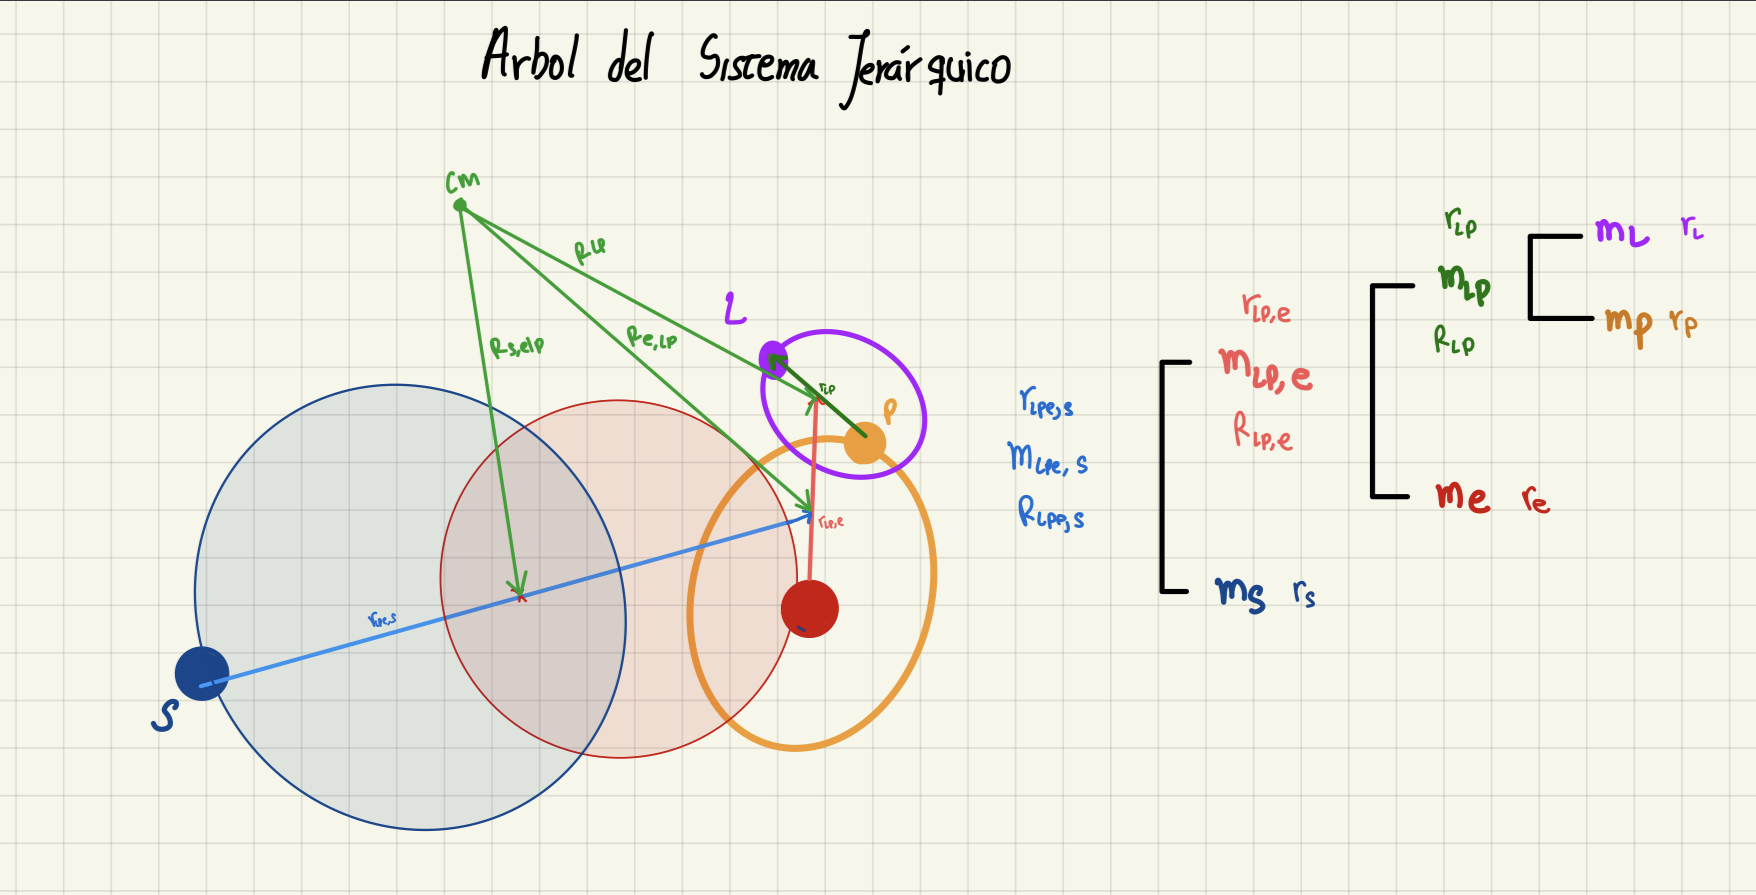

- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.


definimos las condicicones inidicales para cada uno de los sistema

In [ ]:
#definimos las masas
ml= 0.001
mp= 0.01
me= 0.5
ms= 1

#sistema P-L

sistema_pl = [
    dict(m=mp, r=[0,0,0],v=[0,0,0]),
    dict(m=ml, r=[0.03,0,0],v=[0,0.4,0.1]),
]

#sistema e-pl
sistema_epl = [
    dict(m=me, r=[0,0,0],v=[0,0,0]),
    dict(m=ml+mp, r=[0,0.4,0],v=[0.9,0,0.2]),
]

#Sistema s_epl
sistema_sepl = [
    dict(m=ms, r=[0,0,0],v=[0,0,0]),
    dict(m=ml+mp+me, r=[2,3,0],v=[-0.2,0.7,0]),
]

2. Simular usando `ncuerpos_solucion` cada subsistema por separado y obtener el vector y la velocidad relativa como función del tiempo de cada subsistema. Para el tiempo total de simulación encuentre el período orbital de cada subsistema ¿cuánto es?. El tiempo de la simulación será igual al período más largo.



Solucionamos el cada uno de los sistemas

In [ ]:
#Asignamos un tiempo
ts = np.linspace(0,100,500)

#SISTEMA Para P-L
rs1,vs1,rps1,vps1,cuadraturas1 = pc.ncuerpos_solucion(sistema_pl,ts)
#posiciones relativas
rpl = rs1[0,:,:] - rs1[1,:,:]
#velocidades relativas
vpl = vs1[0,:,:] - vs1[1,:,:]


#SISTEMA Para e-pl
rs2,vs2,rps2,vps2,cuadraturas2 = pc.ncuerpos_solucion(sistema_epl,ts)
repl = rs2[0,:,:] - rs2[1,:,:]
vepl = vs2[0,:,:] - vs2[1,:,:]


#SISTEMA Para s-epl
rs3,vs3,rps3,vps3,cuadraturas3 = pc.ncuerpos_solucion(sistema_sepl,ts)
rsepl = rs3[0,:,:] - rs3[1,:,:]
vsepl = vs3[0,:,:] - vs3[1,:,:]


(-2.6181724491941427, 6.26499358782325, -7.788801865552726, 2.2250964522813406)

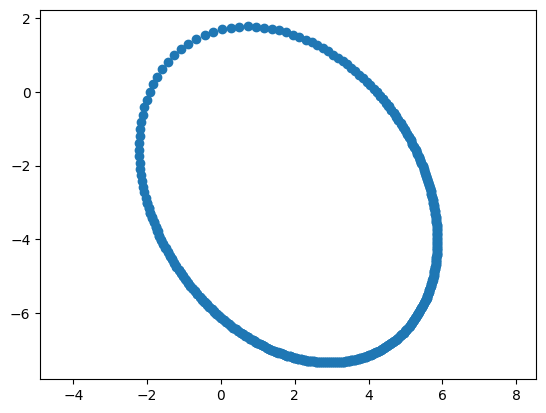

In [ ]:
plt.scatter(x=rsepl[:,0],y=rsepl[:,1])
plt.axis("equal")

A partir de este grafico podemos verificar e utilizar el rango de tiempo seleccionado ya que alcanza a completar una orbita para casa subsistema.

3. Suponiendo que el centro de masa de todo el sistema está en reposo en el origen, calcular a partir la solución al problema relativo de cada subsistema, la posición de cada cuerpo en el tiempo.



Para calular las posición del sistema vamos a utilizar las coordendas de jacobi con la siguientes ecuaciones :

Para el cuerpo mas masiso del sistema:

\begin{equation}
  r⃗_1 = R⃗cm - \frac{m_2}{M} r⃗
\end{equation}

Para el cuerpo menos masiso del sistema:

\begin{equation}
  r⃗_2 = R⃗cm - \frac{m_1}{M} r⃗
\end{equation}

Conociendo que M es la suma de las masas del sistema, Rcm el centro de masa del sistema y r la posicion relativa.


Utilizando el arbol jerarquico ilustrado anteiormente vamos a calcular las posiciones de cada subsistema desde el sistema mas externo al interno.

Para el sistema lpe-s, tomando en cuenta que ms es mas masiso que mlpe, considerando que el centro de masa del este primer sistema es 0.


In [ ]:
#calculo de la posicion para ms

r_s=  (ml+mp+me)/(ml+mp+me+ms)*rsepl
v_s=  (ml+mp+me)/(ml+mp+me+ms)*vsepl

#posicion de Mlpe
r_lpe= - (ms)/(ml+mp+me+ms)*rsepl
v_lpe= - (ms)/(ml+mp+me+ms)*vsepl

Para el sistema lp-e, tomando en cuenta que me es mas masiso que mlp.


In [ ]:
#Posicion de me

r_e= r_lpe + (ml+mp)/(ml+mp+me)*repl
v_e= v_lpe + (ml+mp)/(ml+mp+me)*vepl


#Posicion de mlp
r_lp= r_lpe - (me)/(ml+mp+me)*repl
v_lp= v_lpe - (me)/(ml+mp+me)*vepl

Para el sistema l-p, tomando en cuenta que mp es mas masiso que ml.

In [ ]:
#Posicion mp
r_p= r_lp + (ml)/(ml+mp)*rpl
v_p= v_lp + (ml)/(ml+mp)*vpl


#Posicion ml
r_l= r_lp - (mp)/(ml+mp)*rpl
v_l= v_lp - (mp)/(ml+mp)*vpl

4. Haga gráficos de las posiciones y una animación que muestre la trayectoria de las partículas.



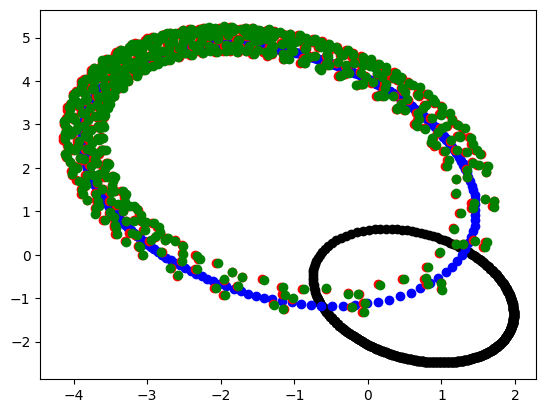

In [ ]:
plt.figure()
plt.plot(r_s[:,0],r_s[:,1],'ko')
plt.plot(r_e[:,0],r_e[:,1],'bo')
plt.plot(r_p[:,0],r_p[:,1],'ro')
plt.plot(r_l[:,0],r_l[:,1],'go')

Animamos

(-4.45389639157858, 2.2886640041936377, -2.866945024070221, 5.642901407439875)

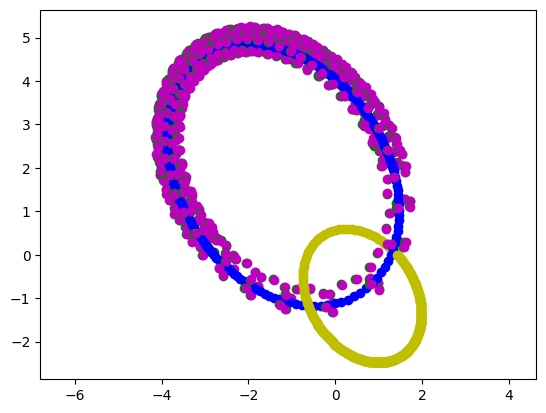

In [ ]:
fig = plt.figure()

c = Camera(fig)
for i in range(500):
  plt.plot(r_s[i,0],r_s[i,1],'yo')
  plt.plot(r_e[i,0],r_e[i,1],'bo')
  plt.plot(r_p[i,0],r_p[i,1],'go')
  plt.plot(r_l[i,0],r_l[i,1],'mo')
  c.snap()
plt.axis("equal")

In [ ]:
anim = c.animate()

In [ ]:
HTML(anim.to_html5_video())

5. Tomando las posiciones iniciales calculadas en 3, use otra vez `ncuerpos_solucion` para encontrar las posiciones y velocidades de todas las partículas respecto del centro de masa. Haga un gráfico de la solución obtenida y cálcule con el obtenido en 4. ¿Se ven parecidas?



Definimos el sistema con todas masas para calcular las posisiciones del sistema para graficarlo, utilizando ncuerpos_solucion

In [ ]:
sistema= [
    dict(m=ms, r=r_s[0],v=v_s[0]),
    dict(m=me, r=r_e[0],v=v_e[0]),
    dict(m=ml, r=r_l[0],v=v_l[0]),
    dict(m=mp, r=r_p[0],v=v_p[0]),
]

t=np.linspace(0,100,500)
rs,vs,rps,vps,cuadraturas = pc.ncuerpos_solucion(sistema,t)

Graficamos

(-4.434359147458608, 2.2892614665491062, -2.866385660393892, 5.639757548321201)

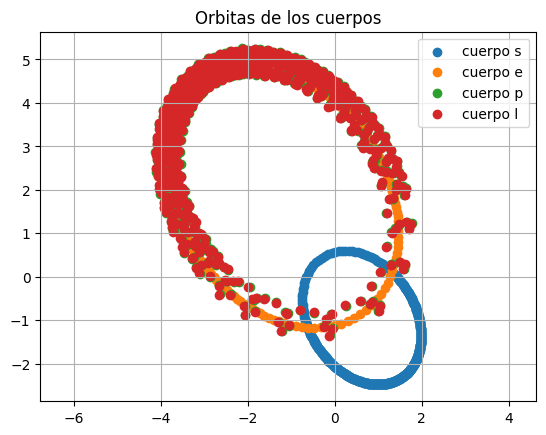

In [ ]:

plt.scatter(x=rps[0,:,0],y=rps[0,:,1],label='cuerpo s') #centro de masa
plt.scatter(x=rps[1,:,0],y=rps[1,:,1],label='cuerpo e')
plt.scatter(x=rps[2,:,0],y=rps[2,:,1],label='cuerpo p')
plt.scatter(x=rps[3,:,0],y=rps[3,:,1],label='cuerpo l')
plt.title("Orbitas de los cuerpos")
plt.grid()
plt.legend()
plt.axis('equal')

A partir de la grafica formada por el porgrama de ncuerpos podemos evidenciar el parecido en las grafica, son practicamente iguales, lo cual comprueba la precisicion de este programa y del procedimiento hecho anteriormente.

6. Haga gráficos de las componentes x, y, z de la posición de cada partícula del sistema a lo largo del tiempo, calculadas con la aproximación jerárquica (punto 3) y con la solución al sistema completo (punto 5). Un gráfico por cuerpo. Comente su resultado.



Cuerpo e

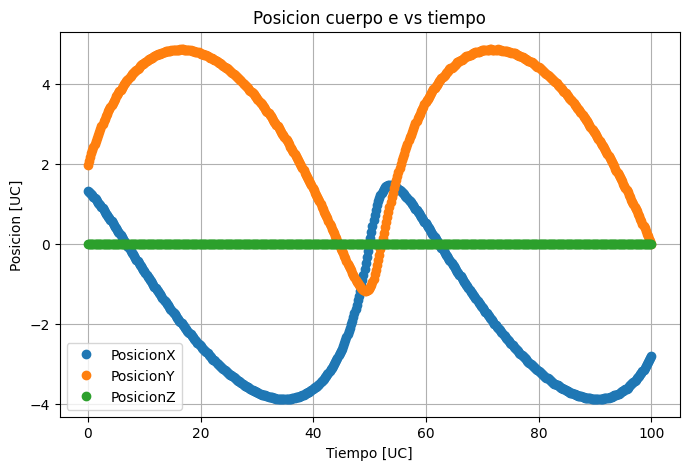

In [ ]:
coo=['X',"Y",'Z'] #definimos coordenadas
plt.figure(figsize=(8,5))
t=np.array(ts)
for i in range(0,3):
  x=r_e[:,i]
  plt.plot(t,x,'o',label=f'Posicion{coo[i]}')
plt.title('Posicion cuerpo e vs tiempo')
plt.legend()
plt.ylabel('Posicion [UC]')
plt.xlabel('Tiempo [UC]')
plt.grid()

Cuerpo s

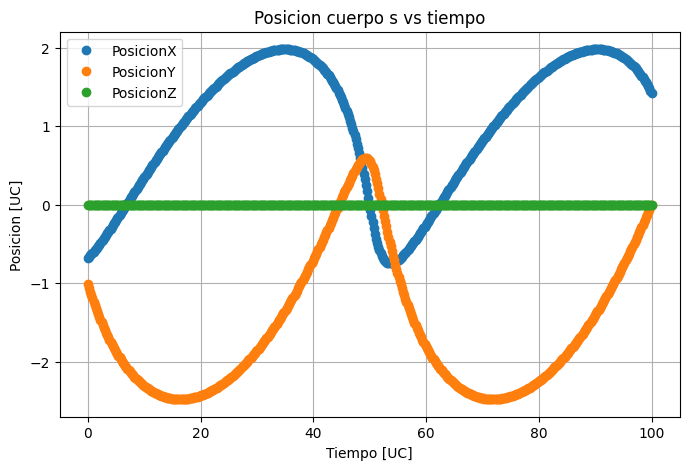

In [ ]:
plt.figure(figsize=(8,5))
for i in range(0,3):
  x=r_s[:,i]
  plt.plot(t,x,'o',label=f'Posicion{coo[i]}')
plt.title('Posicion cuerpo s vs tiempo')
plt.ylabel('Posicion [UC]')
plt.xlabel('Tiempo [UC]')
plt.legend()
plt.grid()

Cuerpo p

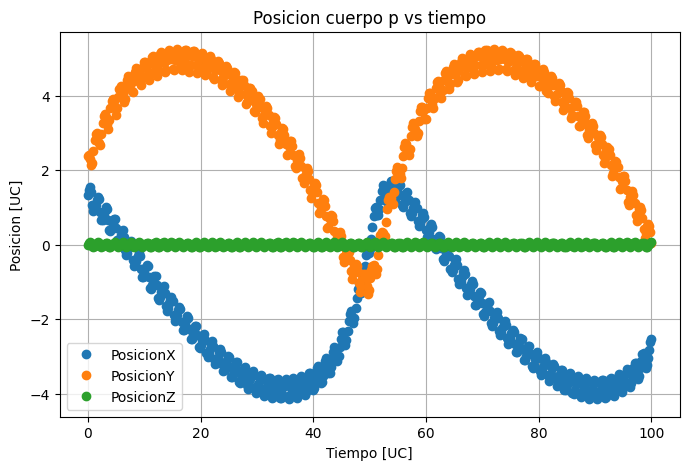

In [ ]:
plt.figure(figsize=(8,5))
t=np.array(ts)
for i in range(0,3):
  x=r_p[:,i]
  plt.plot(t,x,'o',label=f'Posicion{coo[i]}')
plt.title('Posicion cuerpo p vs tiempo')
plt.legend()
plt.ylabel('Posicion [UC]')
plt.xlabel('Tiempo [UC]')
plt.grid()

Cuerpo l

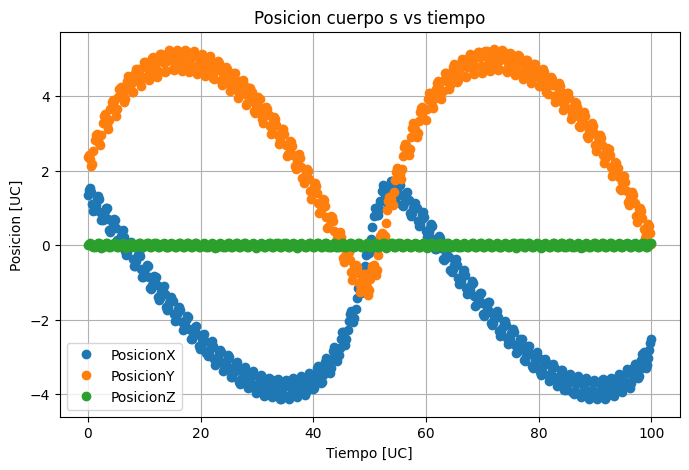

In [ ]:
plt.figure(figsize=(8,5))
t=np.array(ts)
for i in range(0,3):
  x=r_l[:,i]
  plt.plot(t,x,'o',label=f'Posicion{coo[i]}')
  plt.ylabel('Posicion [UC]')
plt.title('Posicion cuerpo s vs tiempo')
plt.xlabel('Tiempo [UC]')
plt.grid()
plt.legend()

A partir de estas graficas se puede ilustrar las osicilaciones de las coordenadas (a excepcion de la coordenada en z), lo cual se debe al movimineto de la orbita lo cual genera estas oscilaciones entre las posiciones de cada cuerpo, estas oscilaciones dependeran de que tan grande es la orbita y tendra una amplitud mucho mayor o una aplitud menor.

7. Haga gráficos de la energía cinética total, la energía potencial total y la energía mecánica total como función del tiempo usando los resultados en 3. El gráfico debe expresarse en unidades más convencionales: en el eje x el tiempo en días,  en el eje y la energía en Joules. ¿Qué observa?

Primero hagamos un analisis de las unidades cononicas del sistema.

Para que el G=1 tenemos que analizar las unidades de longitud masa y tiempo y para que se cumpla esta condicion.

Teniendo en cuenta que las unidades de G esta descrita como
\begin{equation}
  G=\frac{U_L^3}{ U_M U_T^2}
\end{equation}
Siendo $U_L$ unidades de longitud, $U_M$ unidades de masa y $U_T$ unidades de tiempo.

Para este ejercicio tenemos como $U_M = 80$ M$_{\rm Jup}$, $U_L = 0.01$ au, por lo tanto para que G=1, calculamos el valor de  $U_T$ necesario para que esto se cumpla.

\begin{equation}
  U_T=\sqrt{\frac{U_L^3}{U_M}}
\end{equation}



Sacamos la masa de jupiter

In [ ]:
!wget -q  https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc

In [ ]:
import spiceypy as spy
from astropy import constants

In [ ]:
#constantes
G=constants.G.value
AU=constants.au.value

In [ ]:
#Cargar el kernel
spy.furnsh('gm_de440.tpc')

#masa de jupiter
n,dato = spy.bodvrd('599 ','GM',1)
mjup = dato*1e3**3/(G)

calculamos la unidad canonica de tiempo

In [ ]:
UM= 80 *mjup
UL= 0.01 *AU

UT=np.sqrt(UL**3 / UM)
UT

array([0.14848438])

Definimos un array de las posiciones y las velocidades de todos los cuerpos

como Ut esta en segundo segundo hacemos la conversion a dias 1dia=86400s

In [ ]:
masas=np.array([ms,me,mp,ml])*UM
posiciones=np.array([r_s,r_e,r_p,r_l])*UL
velocidades=np.array([v_s,v_e,v_p,v_l])*(UL/UT)*86400

Calculamos la energia potencial

In [ ]:
Up = np.zeros(len(posiciones[0]))
for i in range(len(masas)):
  for j in range(len(masas)):
    if i!=j:
      rij= (posiciones[i]-posiciones[j])
      rij= np.linalg.norm(rij,axis=1)
      U= (1/2)*(- 1* masas[i] * masas[j] )/ rij
      Up +=U


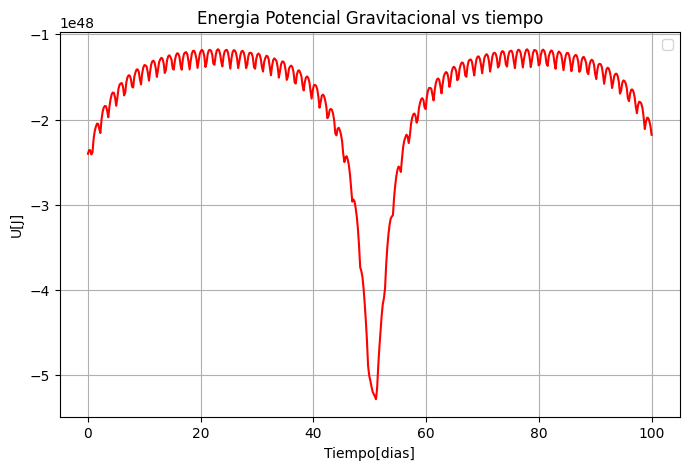

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t,Up,'r')
plt.title(f'Energia Potencial Gravitacional vs tiempo')
plt.xlabel('Tiempo[dias]')
plt.ylabel('U[J]')
plt.legend()
plt.grid()

Calculamos la energia cinetica total

In [ ]:
K=[]
for i in range(len(masas)):
  x=[]
  for j in velocidades[i]:
    v= np.linalg.norm(j)
    a= (1/2)*masas[i]*v**2
    x.append(a)
  K.append(x)


In [ ]:
Kt = []

for i in range(len(posiciones[0])):
    a = 0
    for k in range(len(posiciones)):
        a += K[k][i]
    Kt.append(a)

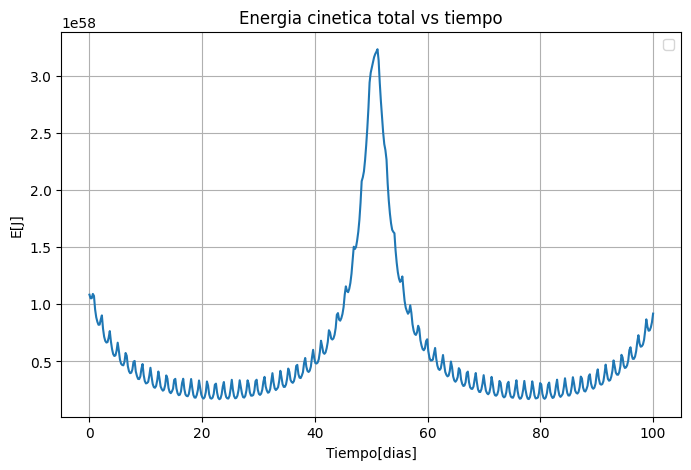

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t,Kt)
plt.title(f'Energia cinetica total vs tiempo')
plt.xlabel('Tiempo[dias]')
plt.ylabel('E[J]')
plt.legend()
plt.grid()

Calculo de la energia total

In [ ]:
E=[]
for i in range(len(Kt)):
  x = Kt[i] + (Up[i])
  E.append(x)


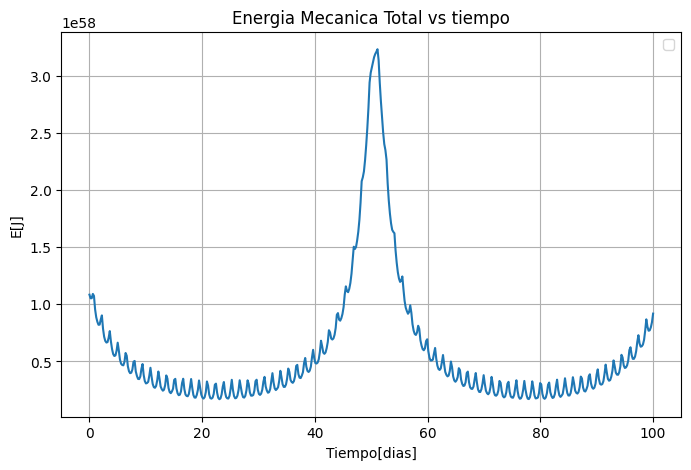

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t,E)
plt.title(f'Energia Mecanica Total vs tiempo')
plt.xlabel('Tiempo[dias]')
plt.ylabel('E[J]')
plt.legend()
plt.grid()

Animacion del sistema lp

(-4.440643284192425, 2.010348749084371, -1.6572592874432495, 5.585297324743353)

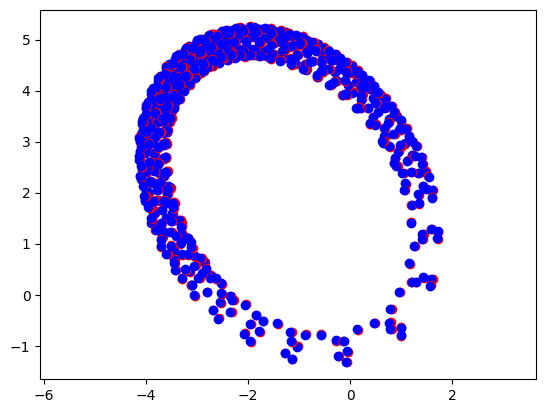

In [ ]:
fig2 = plt.figure()

c2 = Camera(fig2)
for i in range(500):
  plt.plot(r_l[i,0],r_l[i,1],'ro')
  plt.plot(r_p[i,0],r_p[i,1],'bo')
  c2.snap()
plt.axis('equal')


In [ ]:
anim2 = c2.animate()

In [ ]:
HTML(anim2.to_html5_video())